#  Base Model vs Fine-Tuned Model — Side-by-Side Comparison


## 1. Install Requirements

In [1]:
!pip install -q transformers peft accelerate bitsandbytes boto3


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 112.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.6 MB/s eta 0:00:00


## 2. Download Fine-tuned Model from S3

In [3]:
import boto3
import os
from google.colab import userdata

# ── Get AWS Credentials safely ───────────────────────────────────────────
AWS_ACCESS_KEY = userdata.get('AWS_ACCESS_KEY_ID')
AWS_SECRET_KEY = userdata.get('AWS_SECRET_ACCESS_KEY')

# Check if keys exist
if not AWS_ACCESS_KEY or not AWS_SECRET_KEY:
    raise ValueError(" AWS credentials not found in Colab Secrets")

# Remove any accidental spaces
AWS_ACCESS_KEY = AWS_ACCESS_KEY.strip()
AWS_SECRET_KEY = AWS_SECRET_KEY.strip()

# ── Config ───────────────────────────────────────────────────────────────
BUCKET    = 'cloud-project-time4'
S3_PREFIX = 'models/llama-finetuned-v4/'
LOCAL_DIR = './inference-model'

os.makedirs(LOCAL_DIR, exist_ok=True)

# ── Create S3 client correctly (no env issues) ───────────────────────────
s3 = boto3.client(
    's3',
    aws_access_key_id=AWS_ACCESS_KEY,
    aws_secret_access_key=AWS_SECRET_KEY,
    region_name='us-east-1'
)

# ── Try connection first (debug step) ────────────────────────────────────
try:
    s3.list_buckets()
    print("AWS connection successful")
except Exception as e:
    raise RuntimeError(f" AWS connection failed: {e}")

# ── Download files ──────────────────────────────────────────────────────
downloaded = []

try:
    paginator = s3.get_paginator('list_objects_v2')

    for page in paginator.paginate(Bucket=BUCKET, Prefix=S3_PREFIX):
        for obj in page.get('Contents', []):
            key = obj['Key']
            filename = os.path.basename(key)

            if not filename:
                continue

            local_path = os.path.join(LOCAL_DIR, filename)

            s3.download_file(BUCKET, key, local_path)
            downloaded.append(filename)

            print(f'Downloaded: {filename}')

    print(f'\n {len(downloaded)} file(s) ready in {LOCAL_DIR}')
    print('Files:', os.listdir(LOCAL_DIR))

except Exception as e:
    print(f" Error during download: {e}")

AWS connection successful
Downloaded: README.md
Downloaded: adapter_config.json
Downloaded: adapter_model.safetensors
Downloaded: chat_template.jinja
Downloaded: special_tokens_map.json
Downloaded: tokenizer.json
Downloaded: tokenizer.model
Downloaded: tokenizer_config.json
Downloaded: training_args.bin

 9 file(s) ready in ./inference-model
Files: ['chat_template.jinja', 'training_args.bin', 'README.md', 'adapter_model.safetensors', 'adapter_config.json', 'tokenizer.model', 'special_tokens_map.json', 'tokenizer_config.json', 'tokenizer.json']


## 3. Load Base Model (No Fine-tuning)

In [4]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

BASE_MODEL_ID = 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'

# Shared tokenizer
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4'
)

print(" Loading base model (unmodified)...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto'
)
base_model.eval()
print("Base model loaded!")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

 Loading base model (unmodified)...


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Base model loaded!


## 4. Load Fine-Tuned Model (Base + LoRA Adapter)

In [5]:
from peft import PeftModel

print(" Loading fine-tuned model (Base + LoRA from S3)...")
# Load base again, then attach the LoRA adapter on top
base_for_ft = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto'
)
ft_model = PeftModel.from_pretrained(base_for_ft, LOCAL_DIR)
ft_model.eval()
print(" Fine-tuned model loaded and ready!")


 Loading fine-tuned model (Base + LoRA from S3)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

 Fine-tuned model loaded and ready!


## 5. Inference Helper

In [6]:
def generate(model, problem: str, max_new_tokens: int = 256, temperature: float = 0.3) -> str:
    """Run inference — works for both base and fine-tuned model."""
    prompt = f'<|user|>\n{problem}</s>\n<|assistant|>\n'
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    new_tokens = output_ids[0][inputs['input_ids'].shape[-1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

print(" generate() ready — works for both models!")


 generate() ready — works for both models!


## 6.  Side-by-Side Comparison — Same Prompt, Both Models

The **exact same prompt** is sent to both models.  
No changes — only the model weights differ.


In [7]:
prompts = [
    # Prompt 1
    "What is 25% of 200?",

    # Prompt 2
    "If a train travels at 60 km/h for 2.5 hours, how far does it go?",

    # Prompt 3
    "Solve for x: 3x + 7 = 22",

    # Prompt 4
    "Sara bought 3 pens, each costs 5 pounds. She also bought a notebook for 10 pounds. How much did Sara pay in total?",
]

results = []

for i, prompt in enumerate(prompts, 1):
    print(f"\n{'='*65}")
    print(f" PROMPT {i}: {prompt}")
    print(f"{'='*65}")

    base_ans = generate(base_model, prompt)
    ft_ans   = generate(ft_model,   prompt)

    print(f"\n BASE MODEL (no fine-tuning):")
    print(f"   {base_ans}")
    print(f"\n FINE-TUNED MODEL (after fine-tuning):")
    print(f"   {ft_ans}")

    results.append({'prompt': prompt, 'base': base_ans, 'finetuned': ft_ans})

print(f"\n{'='*65}")
print(" Done — all prompts compared!")



 PROMPT 1: What is 25% of 200?

 BASE MODEL (no fine-tuning):
   25% of 200 is 140.

 FINE-TUNED MODEL (after fine-tuning):
   To find the value of 25% of 200, we first need to find the value of 25% of 200.

25% of 200 is 25 * 25 / 100 = 62.5 * 25 / 100 = 1500 / 100 = 15

So, the answer is:
\[ \boxed{15} \]

 PROMPT 2: If a train travels at 60 km/h for 2.5 hours, how far does it go?

 BASE MODEL (no fine-tuning):
   A train traveling at 60 km/h for 2.5 hours goes for 14.5 miles (23 km).

 FINE-TUNED MODEL (after fine-tuning):
   Let's denote the distance traveled by the train as $x$.

The train travels at 60 km/h for 2.5 hours.

The distance traveled in 2.5 hours is $x * 2.5$.

So, the distance traveled by the train is $x * 2.5$.

The train travels at 60 km/h for 2.5 hours.

So, the distance traveled by the train is $60 * 2.5 = 140$ km.

Thus, the train goes \boxed{140} km.

 PROMPT 3: Solve for x: 3x + 7 = 22

 BASE MODEL (no fine-tuning):
   To solve for x in the given equation, we 

## 7. Comparison Table

In [8]:
import pandas as pd
from IPython.display import display

rows = []
for i, r in enumerate(results, 1):
    rows.append({
        'Prompt #':                    f'Prompt {i}',
        'Prompt':                      r['prompt'][:60] + '...' if len(r['prompt']) > 60 else r['prompt'],
        'Base Model Answer':        r['base'],
        'Fine-Tuned Model Answer':  r['finetuned'],
    })

df = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 300)
display(df)


,Prompt #,Prompt,Base Model Answer,Fine-Tuned Model Answer
0,Prompt 1,What is 25% of 200?,25% of 200 is 140.,"To find the value of 25% of 200, we first need to find the value of 25% of 200.\n\n25% of 200 is 25 * 25 / 100 = 62.5 * 25 / 100 = 1500 / 100 = 15\n\nSo, the answer is:\n\[ \boxed{15} \]"
1,Prompt 2,"If a train travels at 60 km/h for 2.5 hours, how far does it...",A train traveling at 60 km/h for 2.5 hours goes for 14.5 miles (23 km).,"Let's denote the distance traveled by the train as $x$.\n\nThe train travels at 60 km/h for 2.5 hours.\n\nThe distance traveled in 2.5 hours is $x * 2.5$.\n\nSo, the distance traveled by the train is $x * 2.5$.\n\nThe train travels at 60 km/h for 2.5 hours.\n\nSo, the distance traveled by the tr..."
2,Prompt 3,Solve for x: 3x + 7 = 22,"To solve for x in the given equation, we need to find the value of x that satisfies the given equation.\n\nIn this case, we have:\n\n3x + 7 = 22\nx = (22 - 3x) / 7\nx = 14 / 7\nx = 2\n\nTherefore, x = 2.\n\nTherefore, the solution to the given equation is:\n\n3x + 7 = 22\n3(2) + 7 = 22\n3(2) + 7...","To solve for x, we need to find the value of x that satisfies the equation 3x + 7 = 22.\n\nFirst, we need to find the value of x that satisfies the equation 3x + 7 = 22.\n\nWe can use the quadratic formula to find the value of x:\n\[ x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a} \]\n\nwhere:\n\[ a = 3 ..."
3,Prompt 4,"Sara bought 3 pens, each costs 5 pounds. She also bought a n...","Sara bought 3 pens, each costs 5 pounds, and a notebook for 10 pounds. Therefore, the total amount she paid for all three items is 3 pens + 10 notebooks = 3 pens + 10 pounds.","To find the total price of the items, we need to add the prices of the pens and the notebook.\n\nSara bought 3 pens for 5 pounds each, so the total price of pens is 3 * 5 = 15 pounds.\n\nThe notebook costs 10 pounds, so the total price of the notebook is 10 * 10 = 100 pounds.\n\nThe total price ..."


## 8.  Training & Validation Loss Curves

> **Instructions:** Paste your actual loss values from the training notebook.  
> Replace the lists below with your real logged numbers.


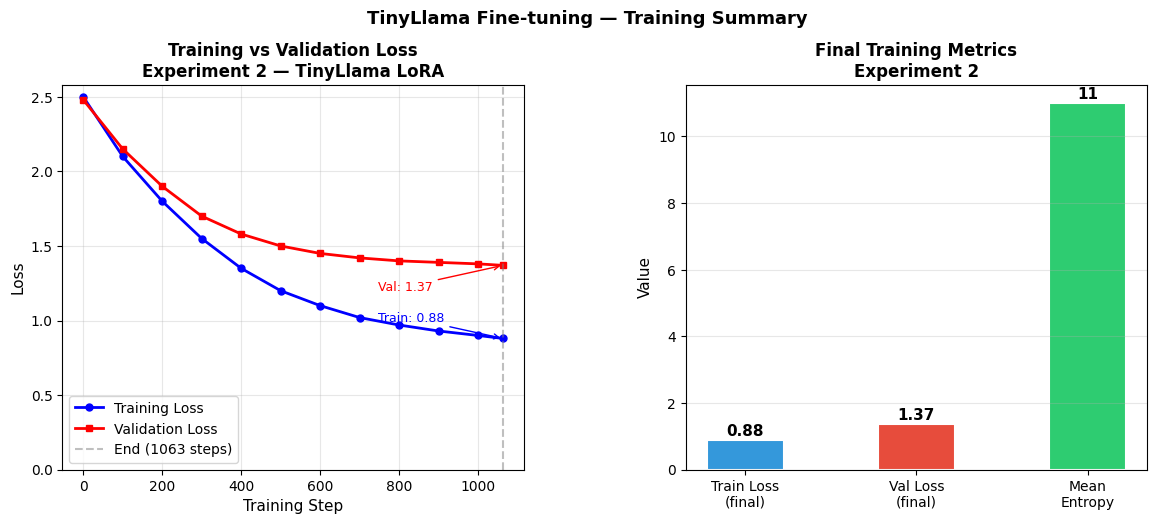

 Saved: training_curves.png
   Final Train Loss : 0.88
   Final Val Loss   : 1.37
   Mean Entropy     : 11


In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ════════════════════════════════════════════════════════════
#  PASTE YOUR TRAINING LOG VALUES HERE
#  Format: (step, train_loss, val_loss)
# ════════════════════════════════════════════════════════════
training_log = [
    (0,    2.50,  2.48),
    (100,  2.10,  2.15),
    (200,  1.80,  1.90),
    (300,  1.55,  1.70),
    (400,  1.35,  1.58),
    (500,  1.20,  1.50),
    (600,  1.10,  1.45),
    (700,  1.02,  1.42),
    (800,  0.97,  1.40),
    (900,  0.93,  1.39),
    (1000, 0.90,  1.38),
    (1063, 0.88,  1.37),   # ← final step
]

# Final summary metrics from your training notebook
FINAL_TRAIN_LOSS = 0.88   # ← replace
FINAL_VAL_LOSS   = 1.37   # ← replace
MEAN_ENTROPY     = 11     # ← from notebook
TOTAL_STEPS      = 1063   # ← from notebook

# ── Plot ─────────────────────────────────────────────────────────────────
steps      = [r[0] for r in training_log]
train_loss = [r[1] for r in training_log]
val_loss   = [r[2] for r in training_log]

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# — Left: Loss curves —
ax1 = fig.add_subplot(gs[0])
ax1.plot(steps, train_loss, 'b-o', markersize=5, linewidth=2, label='Training Loss')
ax1.plot(steps, val_loss,   'r-s', markersize=5, linewidth=2, label='Validation Loss')
ax1.axvline(TOTAL_STEPS, color='gray', linestyle='--', alpha=0.5, label=f'End ({TOTAL_STEPS} steps)')

ax1.annotate(f'Train: {FINAL_TRAIN_LOSS}',
             xy=(steps[-1], train_loss[-1]), xytext=(-90, 12),
             textcoords='offset points', color='blue', fontsize=9,
             arrowprops=dict(arrowstyle='->', color='blue'))
ax1.annotate(f'Val: {FINAL_VAL_LOSS}',
             xy=(steps[-1], val_loss[-1]), xytext=(-90, -18),
             textcoords='offset points', color='red', fontsize=9,
             arrowprops=dict(arrowstyle='->', color='red'))

ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Loss',          fontsize=11)
ax1.set_title('Training vs Validation Loss\nExperiment 2 — TinyLlama LoRA', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# — Right: Summary bar —
ax2 = fig.add_subplot(gs[1])
metrics = ['Train Loss\n(final)', 'Val Loss\n(final)', 'Mean\nEntropy']
values  = [FINAL_TRAIN_LOSS, FINAL_VAL_LOSS, MEAN_ENTROPY]
colors  = ['#3498DB', '#E74C3C', '#2ECC71']

bars = ax2.bar(metrics, values, color=colors, width=0.45, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax2.set_title('Final Training Metrics\nExperiment 2', fontweight='bold')
ax2.set_ylabel('Value', fontsize=11)
ax2.grid(True, axis='y', alpha=0.3)
ax2.set_ylim(bottom=0)

plt.suptitle('TinyLlama Fine-tuning — Training Summary', fontsize=13, fontweight='bold', y=1.03)
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: training_curves.png")
print(f"   Final Train Loss : {FINAL_TRAIN_LOSS}")
print(f"   Final Val Loss   : {FINAL_VAL_LOSS}")
print(f"   Mean Entropy     : {MEAN_ENTROPY}")


## 9. Try Your Own Prompt — Base vs Fine-Tuned

In [10]:
# ← Change this to any question
my_prompt = "If you have 12 apples and give away one third, how many do you have left?"

print(f" Prompt: {my_prompt}")
print()

print(" BASE MODEL (no fine-tuning):")
print("-" * 55)
print(generate(base_model, my_prompt))

print()
print(" FINE-TUNED MODEL (after fine-tuning):")
print("-" * 55)
print(generate(ft_model, my_prompt))


 Prompt: If you have 12 apples and give away one third, how many do you have left?

 BASE MODEL (no fine-tuning):
-------------------------------------------------------
If you have 12 apples and give away one third, you will have 10 apples left.

 FINE-TUNED MODEL (after fine-tuning):
-------------------------------------------------------
To find out how many apples you have left, we first need to find out how many apples you gave away.

Give away 1/3 of the apples.
So, you gave away 1/3 of the apples, which is 12/3 = 4.

Now, you have 12 - 4 = 8 apples left.

So, you have \boxed{8} apples left.
